In [1]:
!pip install -q wfdb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import cv2
import wfdb

from scipy.stats import ttest_ind, chi2_contingency, f_oneway
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("All libraries installed and imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.2 MB/s eta 0:00:00
All libraries installed and imported successfully!


**Dataset Acquisition + Loading + Inspection + Cleaning**

In [2]:
# ==============================
# PART A - TABULAR DATA
# PIMA INDIANS DIABETES DATASET
# ==============================

# Download dataset
!wget -q https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv

# Column names
columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# Load dataset
df = pd.read_csv(
    'pima-indians-diabetes.data.csv',
    names=columns
)

print("First 5 rows:")
display(df.head())

print("\nDataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nOriginal Missing Values:")
print(df.isnull().sum())

# Healthcare-specific missing values
medical_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

print("\nZero values representing possible missing measurements:")
for col in medical_columns:
    print(col, ":", (df[col] == 0).sum())

# Replace invalid zeros with NaN
df[medical_columns] = df[medical_columns].replace(0, np.nan)

# Fill missing values with median
for col in medical_columns:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Shape: (768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Original Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zero values representing possible missing measurements:
Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11

Missing Values After Cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BM

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Completing EDA**

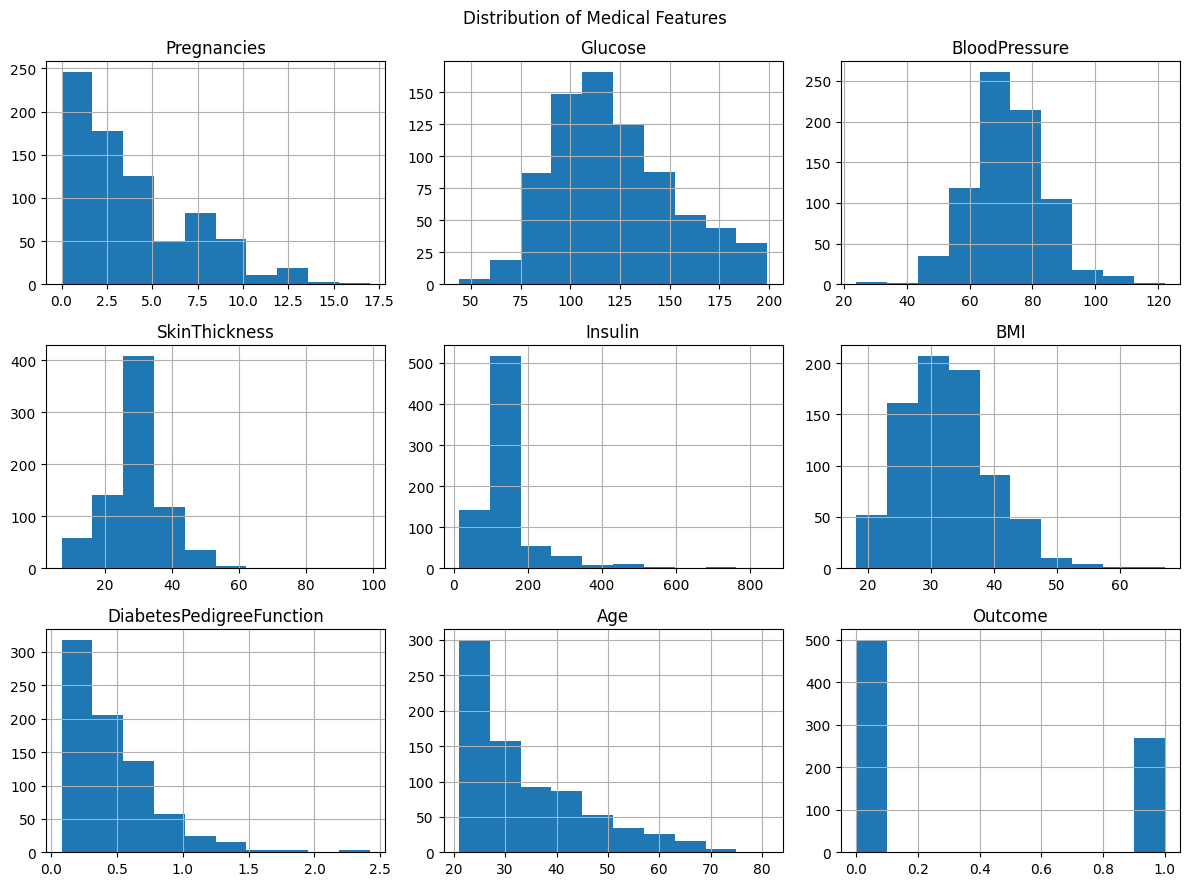

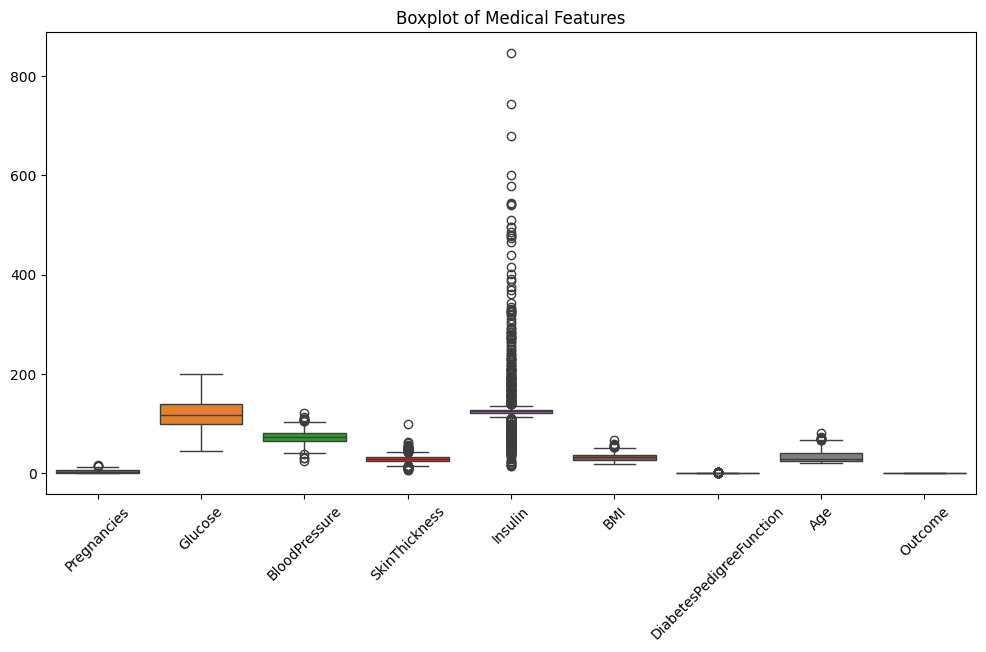

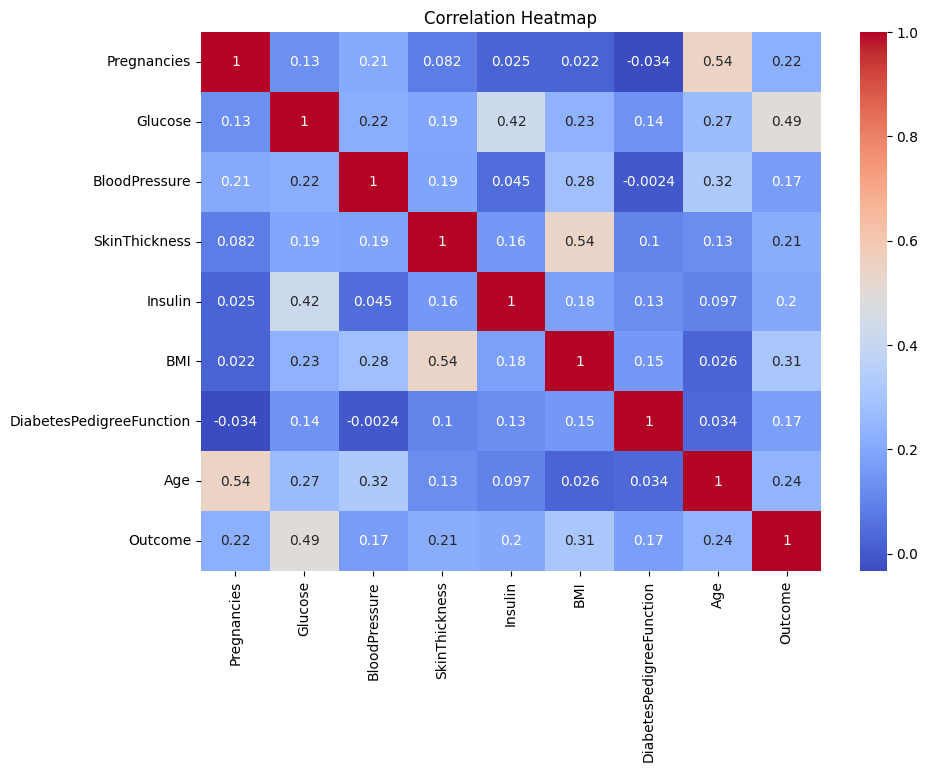

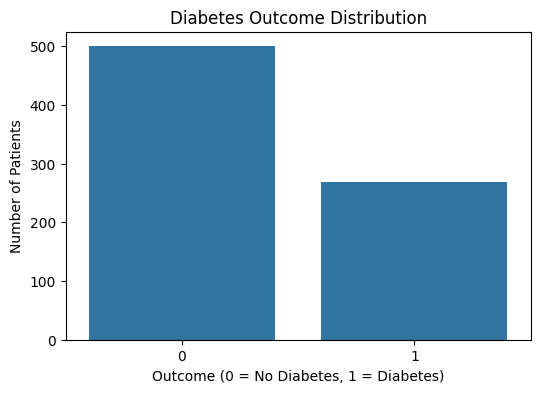

In [3]:
# ==============================
# EXPLORATORY DATA ANALYSIS
# ==============================

# Histograms
df.hist(figsize=(12, 9))
plt.suptitle("Distribution of Medical Features")
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title("Boxplot of Medical Features")
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

# Outcome distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")
plt.show()

** Hypothesis + Chi-Square + ANOVA**

In [4]:
# ==============================
# STATISTICAL TESTS
# ==============================

# ---------- HYPOTHESIS TEST / T-TEST ----------
diabetic = df[df['Outcome'] == 1]['Glucose']
non_diabetic = df[df['Outcome'] == 0]['Glucose']

t_stat, t_p = ttest_ind(
    diabetic,
    non_diabetic
)

print("========== HYPOTHESIS TEST ==========")
print("H0: Mean glucose is the same for both groups.")
print("H1: Mean glucose is different between the groups.")
print("T-statistic:", t_stat)
print("P-value:", t_p)

if t_p < 0.05:
    print("Decision: Reject H0")
    print("Conclusion: Significant difference exists.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: No significant difference found.")


# ---------- CHI-SQUARE TEST ----------
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[20, 30, 40, 50, 100],
    labels=['20-30', '31-40', '41-50', '51+']
)

table = pd.crosstab(
    df['AgeGroup'],
    df['Outcome']
)

chi2, chi_p, dof, expected = chi2_contingency(table)

print("\n========== CHI-SQUARE TEST ==========")
display(table)
print("Chi-square:", chi2)
print("P-value:", chi_p)

if chi_p < 0.05:
    print("Decision: Reject H0")
    print("Conclusion: Age group and diabetes outcome are associated.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: No significant association found.")


# ---------- ANOVA ----------
groups = [
    group['Glucose'].values
    for name, group in df.groupby(
        'AgeGroup',
        observed=True
    )
]

f_stat, anova_p = f_oneway(*groups)

print("\n========== ANOVA ==========")
print("H0: Mean glucose is the same across age groups.")
print("H1: At least one group has a different mean.")
print("F-statistic:", f_stat)
print("P-value:", anova_p)

if anova_p < 0.05:
    print("Decision: Reject H0")
    print("Conclusion: Significant difference exists.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: No significant difference found.")

========== HYPOTHESIS TEST ==========
H0: Mean glucose is the same for both groups.
H1: Mean glucose is different between the groups.
T-statistic: 15.673795182294105
P-value: 3.1287190418423694e-48
Decision: Reject H0
Conclusion: Significant difference exists.

========== CHI-SQUARE TEST ==========


Outcome,0,1
AgeGroup,,
20-30,327,90
31-40,81,76
41-50,49,64
51+,43,38


Chi-square: 73.80892085951109
P-value: 6.521685313585261e-16
Decision: Reject H0
Conclusion: Age group and diabetes outcome are associated.

========== ANOVA ==========
H0: Mean glucose is the same across age groups.
H1: At least one group has a different mean.
F-statistic: 19.733198998160084
P-value: 2.5012447956304365e-12
Decision: Reject H0
Conclusion: Significant difference exists.


**Feature Engineering + Feature Selection + Scaling**

In [5]:
# ==============================
# FEATURE ENGINEERING
# FEATURE SELECTION
# FEATURE SCALING
# ==============================

# Feature Engineering
df['BMI_Category'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=[
        'Underweight',
        'Normal',
        'Overweight',
        'Obese'
    ]
)

df['Age_Category'] = pd.cut(
    df['Age'],
    bins=[0, 30, 50, 100],
    labels=[
        'Young',
        'Middle',
        'Senior'
    ]
)

print("New engineered features:")
display(
    df[
        ['BMI', 'BMI_Category',
         'Age', 'Age_Category']
    ].head()
)

# Features and target
features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

X = df[features]
y = df['Outcome']

# Feature Selection
selector = SelectKBest(
    score_func=f_classif,
    k=5
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[
    selector.get_support()
]

print("\nSelected Features:")
print(list(selected_features))

# Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled data shape:", X_scaled.shape)

New engineered features:


,BMI,BMI_Category,Age,Age_Category
0,33.6,Obese,50,Middle
1,26.6,Overweight,31,Middle
2,23.3,Normal,32,Middle
3,28.1,Overweight,21,Young
4,43.1,Obese,33,Middle



Selected Features:
['Pregnancies', 'Glucose', 'SkinThickness', 'BMI', 'Age']

Scaled data shape: (768, 8)


**Complete Text Processing**

In [10]:
!find /content -type f -name "*.csv"

/content/pima-indians-diabetes.data.csv
/content/mtsamples.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv


**Download + Extract + Inspect Images**

In [17]:
# ==========================================
# PART C - CHEST X-RAY DATASET
# DOWNLOAD AND EXTRACT
# ==========================================

import os
import zipfile
import shutil

# Remove old broken files/folders if they exist
if os.path.exists("/content/chest_xray.zip"):
    os.remove("/content/chest_xray.zip")

if os.path.exists("/content/chest_xray_dataset"):
    shutil.rmtree("/content/chest_xray_dataset")

# Download dataset from Kaggle
!wget -q --show-progress \
"https://www.kaggle.com/api/v1/datasets/download/paultimothymooney/chest-xray-pneumonia" \
-O /content/chest_xray.zip

# Check downloaded file
file_size = os.path.getsize("/content/chest_xray.zip")

print("\nDownloaded file size:",
      round(file_size / (1024 * 1024), 2),
      "MB")

# Check that it is actually a ZIP file
if not zipfile.is_zipfile("/content/chest_xray.zip"):
    raise Exception(
        "Download failed: the downloaded file is not a valid ZIP file."
    )

# Extract
with zipfile.ZipFile(
    "/content/chest_xray.zip",
    "r"
) as zip_ref:
    zip_ref.extractall(
        "/content/chest_xray_dataset"
    )

print("Dataset extracted successfully!")

# Find train folder automatically
DATASET_ROOT = "/content/chest_xray_dataset"

TRAIN_DIR = None

for root, dirs, files in os.walk(DATASET_ROOT):

    if (
        "NORMAL" in dirs
        and "PNEUMONIA" in dirs
        and os.path.basename(root).lower() == "train"
    ):
        TRAIN_DIR = root
        break

print("\nTraining folder:", TRAIN_DIR)

# Verify
if TRAIN_DIR is None:
    print("\nCould not find the train folder.")
    print("Available folders:")
    !find /content/chest_xray_dataset -maxdepth 4 -type d
else:
    print("\nDataset is ready!")


/content/chest_xray 100%[===================>]   2.29G   109MB/s    in 18s     

Downloaded file size: 2349.25 MB
Dataset extracted successfully!

Training folder: /content/chest_xray_dataset/chest_xray/__MACOSX/chest_xray/train

Dataset is ready!


**Image EDA + Preprocessing + Augmentation**

Real training folder:
/content/chest_xray_dataset/chest_xray/chest_xray/train

Normal folder:
/content/chest_xray_dataset/chest_xray/chest_xray/train/NORMAL

Pneumonia folder:
/content/chest_xray_dataset/chest_xray/chest_xray/train/PNEUMONIA

Normal images: 1341
Pneumonia images: 3875

Normal image loaded successfully!


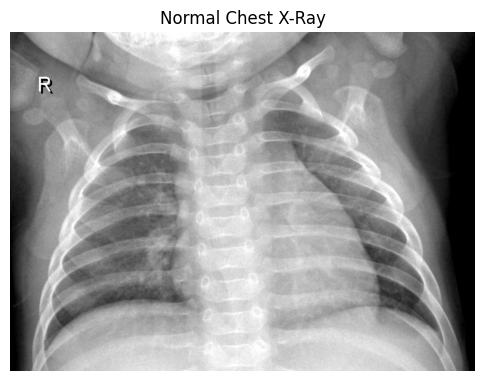

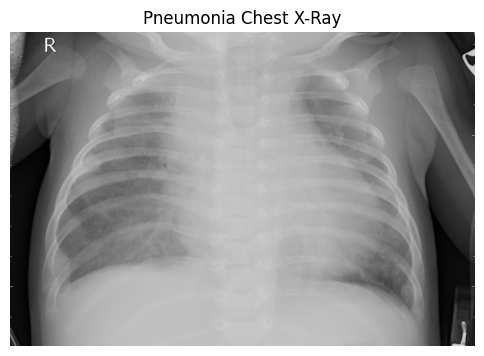


Original image shape: (924, 1268, 3)
Resized image shape: (224, 224, 3)
Normalized range: 0.0 to 1.0


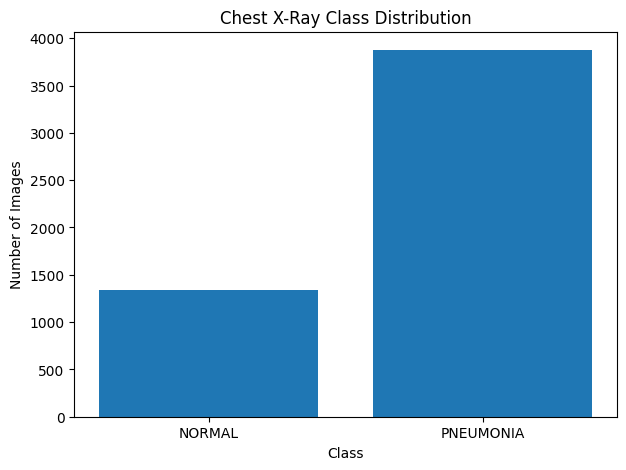


Class Distribution:
NORMAL: 1341
PNEUMONIA: 3875
Found 5216 images belonging to 2 classes.

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


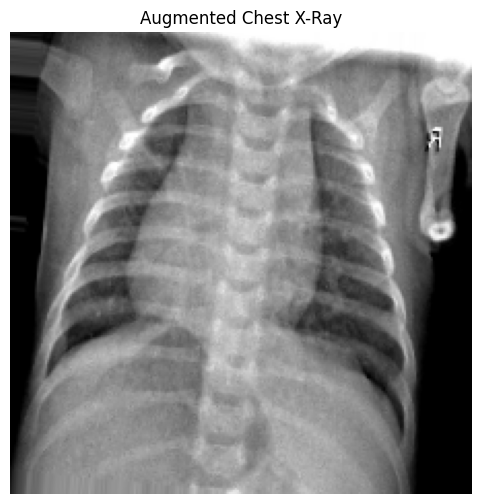


Image preprocessing and augmentation completed successfully!


In [19]:
# ==========================================
# PART C - IMAGE PROCESSING
# CHEST X-RAY PNEUMONIA
# ==========================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# ==========================================
# 1. FIND THE REAL TRAIN FOLDER
# ==========================================

DATASET_ROOT = "/content/chest_xray_dataset"

TRAIN_DIR = None

for root, dirs, files in os.walk(DATASET_ROOT):

    # Ignore Mac metadata folder
    if "__MACOSX" in root:
        continue

    if (
        os.path.basename(root).lower() == "train"
        and "NORMAL" in dirs
        and "PNEUMONIA" in dirs
    ):
        TRAIN_DIR = root
        break

if TRAIN_DIR is None:
    raise FileNotFoundError(
        "Real train folder was not found."
    )

print("Real training folder:")
print(TRAIN_DIR)


# ==========================================
# 2. CREATE CLASS PATHS
# ==========================================

normal_path = os.path.join(
    TRAIN_DIR,
    "NORMAL"
)

pneumonia_path = os.path.join(
    TRAIN_DIR,
    "PNEUMONIA"
)

print("\nNormal folder:")
print(normal_path)

print("\nPneumonia folder:")
print(pneumonia_path)


# ==========================================
# 3. GET ONLY REAL IMAGE FILES
# ==========================================

image_extensions = (
    ".jpeg",
    ".jpg",
    ".png"
)

normal_files = [
    f for f in os.listdir(normal_path)
    if f.lower().endswith(image_extensions)
]

pneumonia_files = [
    f for f in os.listdir(pneumonia_path)
    if f.lower().endswith(image_extensions)
]

print("\nNormal images:", len(normal_files))
print("Pneumonia images:", len(pneumonia_files))


# ==========================================
# 4. LOAD NORMAL IMAGE SAFELY
# ==========================================

normal_file = normal_files[0]

normal_img_path = os.path.join(
    normal_path,
    normal_file
)

normal_img = cv2.imread(
    normal_img_path
)

if normal_img is None:
    raise ValueError(
        "Normal X-ray image could not be loaded."
    )

print("\nNormal image loaded successfully!")


# ==========================================
# 5. DISPLAY NORMAL X-RAY
# ==========================================

plt.figure(figsize=(6, 6))

plt.imshow(
    cv2.cvtColor(
        normal_img,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Normal Chest X-Ray")
plt.axis("off")
plt.show()


# ==========================================
# 6. LOAD PNEUMONIA IMAGE
# ==========================================

pneumonia_file = pneumonia_files[0]

pneumonia_img_path = os.path.join(
    pneumonia_path,
    pneumonia_file
)

pneumonia_img = cv2.imread(
    pneumonia_img_path
)

if pneumonia_img is None:
    raise ValueError(
        "Pneumonia X-ray image could not be loaded."
    )


# ==========================================
# 7. DISPLAY PNEUMONIA X-RAY
# ==========================================

plt.figure(figsize=(6, 6))

plt.imshow(
    cv2.cvtColor(
        pneumonia_img,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Pneumonia Chest X-Ray")
plt.axis("off")
plt.show()


# ==========================================
# 8. RESIZE IMAGE
# ==========================================

resized_img = cv2.resize(
    normal_img,
    (224, 224)
)

print("\nOriginal image shape:",
      normal_img.shape)

print("Resized image shape:",
      resized_img.shape)


# ==========================================
# 9. NORMALIZE IMAGE
# ==========================================

normalized_img = (
    resized_img / 255.0
)

print(
    "Normalized range:",
    normalized_img.min(),
    "to",
    normalized_img.max()
)


# ==========================================
# 10. CLASS DISTRIBUTION
# ==========================================

classes = [
    "NORMAL",
    "PNEUMONIA"
]

counts = [
    len(normal_files),
    len(pneumonia_files)
]

plt.figure(figsize=(7, 5))

plt.bar(
    classes,
    counts
)

plt.title(
    "Chest X-Ray Class Distribution"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

print("\nClass Distribution:")
print("NORMAL:", counts[0])
print("PNEUMONIA:", counts[1])


# ==========================================
# 11. IMAGE AUGMENTATION
# ==========================================

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

image_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

images, labels = next(
    image_generator
)

print(
    "\nImage batch shape:",
    images.shape
)

print(
    "Label batch shape:",
    labels.shape
)


# ==========================================
# 12. DISPLAY AUGMENTED IMAGE
# ==========================================

plt.figure(figsize=(6, 6))

plt.imshow(images[0])

plt.title(
    "Augmented Chest X-Ray"
)

plt.axis("off")
plt.show()

print(
    "\nImage preprocessing and augmentation completed successfully!"
)

**Load + Inspect ECG**

ECG loaded successfully!
Sampling Frequency: 360
Number of Signals: 2
Signal Length: 650000
Signal Shape: (650000, 2)


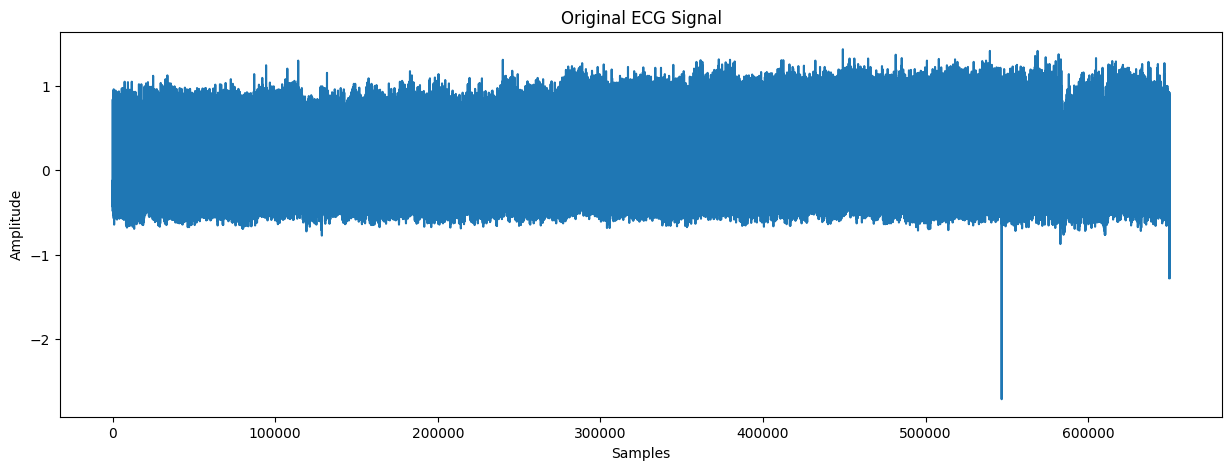

In [20]:
# ==============================
# PART D - SIGNAL DATA
# MIT-BIH ARRHYTHMIA DATABASE
# ==============================

# Load ECG record
record = wfdb.rdrecord(
    '100',
    pn_dir='mitdb'
)

signal = record.p_signal

print("ECG loaded successfully!")

print("Sampling Frequency:",
      record.fs)

print("Number of Signals:",
      record.n_sig)

print("Signal Length:",
      record.sig_len)

print("Signal Shape:",
      signal.shape)

# Plot ECG
plt.figure(figsize=(15, 5))

plt.plot(signal[:, 0])

plt.title("Original ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

**ECG Noise Removal + Windows + Analysis**

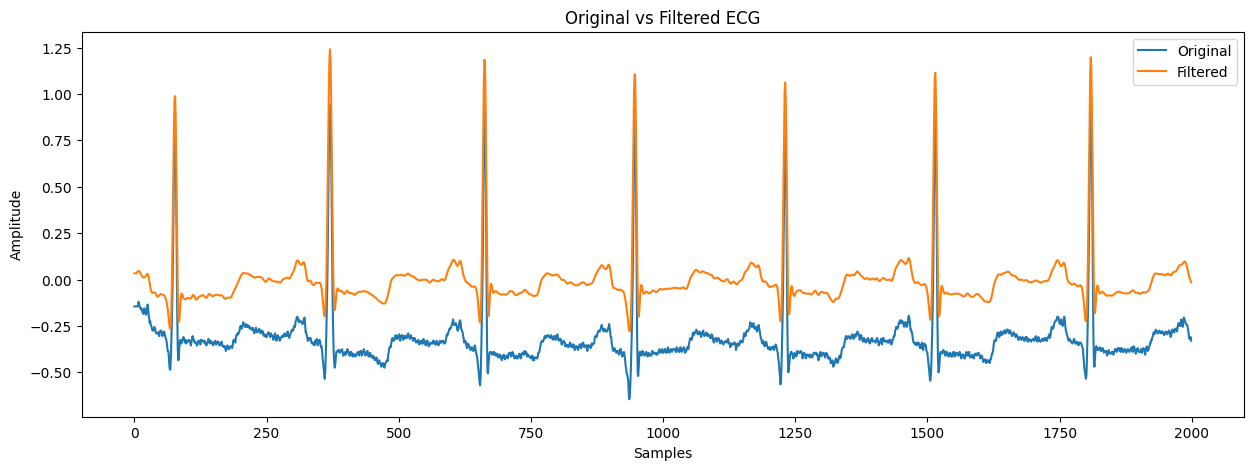

Signal windows shape: (1299, 500)


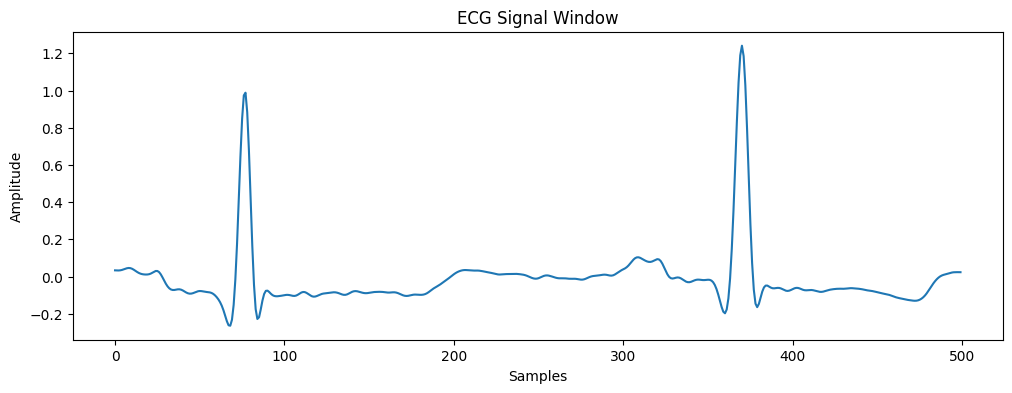

Mean: 1.9945031269914422e-05
Standard Deviation: 0.1830483587448914
Minimum: -2.4590838720137493
Maximum: 2.1511476125504942


In [21]:
# ==============================
# ECG FILTERING / NOISE REMOVAL
# SIGNAL WINDOWING
# ==============================

# Bandpass filter
def bandpass_filter(
    signal,
    lowcut,
    highcut,
    fs,
    order=4
):
    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype='band'
    )

    return filtfilt(
        b,
        a,
        signal
    )


fs = record.fs

filtered_signal = bandpass_filter(
    signal[:, 0],
    0.5,
    40,
    fs
)

# Original vs filtered
plt.figure(figsize=(15, 5))

plt.plot(
    signal[:2000, 0],
    label='Original'
)

plt.plot(
    filtered_signal[:2000],
    label='Filtered'
)

plt.title("Original vs Filtered ECG")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.legend()
plt.show()


# Signal windowing
window_size = 500

windows = []

for i in range(
    0,
    len(filtered_signal) - window_size,
    window_size
):
    windows.append(
        filtered_signal[
            i:i + window_size
        ]
    )

windows = np.array(windows)

print(
    "Signal windows shape:",
    windows.shape
)

# Display one window
plt.figure(figsize=(12, 4))

plt.plot(windows[0])

plt.title("ECG Signal Window")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

# Signal statistics
print("Mean:", np.mean(filtered_signal))
print(
    "Standard Deviation:",
    np.std(filtered_signal)
)
print(
    "Minimum:",
    np.min(filtered_signal)
)
print(
    "Maximum:",
    np.max(filtered_signal)
)